Un número complejo tiene la forma:

z = a + bi

Donde:
- a = parte real
- b = parte imaginaria

Un cuaternión es una extensión de eso:

q = a + bi + cj + dk

Donde:
- a = parte escalar (real)
- b,c,d = componentes vectoriales (imaginarios)

Como un cuaternión es q=a+bi+cj+dk la clase de Python sólo necesita guardar esos 4 valores.

*Quaternion(a, b, c, d)*

**Nota:** En Python los métodos que empiezan y terminan con doble guión bajo (__) son llamados *dunder methods* y son especiales porque Python los llama automáticamente cuando se usan operadores como "+", "*", o cuando se imprime un objeto.

In [43]:
class Quaternion:
    def __init__(self, a, b, c, d):
        self.a = a  # Parte escalar (real)
        self.b = b  # coeficiente de i
        self.c = c  # coeficiente de j
        self.d = d  # coeficiente de k
        
    #Representación legible
    def __repr__(self):
        def _term(val, symbol):
            sign = "+" if val >=0 else "-"
            return f"{sign} {abs(val)}{symbol}"
        return f"({self.a}{_term(self.b,'i')}{_term(self.c,'j')}{_term(self.d,'k')})"

*self* es lo equivalente a *this* en otros lenguajes. *__ init__* es el constructor.

El constructor es una función especial que se ejecuta automáticamente cuando creas un objeto. La clase que se usa es "el molde" para fabricar esos objetos.

El self representa el objeto que se está creando o usando en ese momento.

In [44]:
print(Quaternion(1,2,-3,4))

(1+ 2i- 3j+ 4k)


**Suma y resta**

Al igual que con los números complejos, la suma de cuaterniones es componente a componente (cucarachas con cucarachas y lagartijas con lagartijas).

(a₁+b₁i+c₁j+d₁k) + (a₂+b₂i+c₂j+d₂k) = (a₁+a₂) + (b₁+b₂)i + (c₁+c₂)j + (d₁+d₂)k

In [45]:
def __add__(self, other):
    return Quaternion(self.a + other.a, 
                      self.b + other.b,
                      self.c + other.c,
                      self.d + other.d)

def __sub__(self, other):
    return Quaternion(self.a - other.a, 
                      self.b - other.b,
                      self.c - other.c,
                      self.d - other.d)

**Conjugado y norma**

**CONJUGADO**

q* se lee como *"q conjugado"* o *"el conjugado de q"*. Y es exactamente la misma idea que el conjugado en números complejos.

Si se tiene: 

3 + 4i

su conjugado es: 

3 - 4i

**Se deja igual la parte real y se cambia el signo de la parte imaginaria.**

Con los cuaterniones ocurre lo mismo:

Si

q = a + bi + cj + dk

entonces:

q* = a - bi - cj - dk

Simplemente se cambia el signo de toda la parte vectorial.

**NORMA**

Las barras simples suelen indicar valor absoluto ( |x| ). Por ejemplo:

|-5|=5

Y las dobles barras ( ||*v*|| ) se usan para **indicar norma o longitud** para vectores, matrices o cuaterniones.



Entonces, ‖q‖ es la norma, y se lee como *"norma de q"* o *"magnitud de q"* o *"longitud de q"*.

Pensando en vectores, si se tiene el vector (3,4), entonces su longitud es:

√(3^2) + (4^2) = 5  <- (Teorema de pitágoras)

Entonces, la norma de un cuaternión es exactamente la misma idea, pero con cuatro componentes:

‖q‖ = √(a² + b² + c² + d²)

Y una propiedad clave que se usará más adelante es:

q · q* = ‖q‖² 

Esta propiedad dice que si se multiplica un cuaternión por su conjugado se obtiene un número real.

Por ejemplo, para

q = 1 + 2i + 3j + 4k

q·q* = 1² + 2² + 3² + 4² = 30

Y como ‖q‖ = √30

Entonces 

‖q‖² = 30

Por eso

q · q* = ‖q‖² 
 
Esta propiedad siempre da un número real positivo.

In [46]:
def conjugate(self):
    return Quaternion(self.a, -self.b, -self.c, -self.d)

def norm(self):
    return (self.a**2 + self.b**2 + self.c**2 + self.d**2) ** 0.5 # Elevar a la 0.5 (1/2) equivale a sacar la raíz cuadrada

def normalize(self):
    n = self.norm()
    if n == 0:
        raise ValueError("El cuaternión cero no se puede normalizar.")
    return Quaternion(self.a/n, self.b/n, self.c/n, self.d/n)

Sobre la función *normalize()*...

La normalización toma cualquier cuaternión y lo convierte en uno cuya norma vale exactamente 1.

Si tuviera q = (1,2,3,4) su norma es √30. Entonces para normalizar se dividiría todo entre √30:

[(1/√30), (2/√30), (3/√30), (4/√30)] = 1

Esto es útil porque los **cuaterniones unitarios** (norma=1) son los que se usan para representar rotaciones en gráficos 3D, robótica, videojuegos y visión por computadora.

**RESUMEN:**

Conjugado (q*) → cambia el signo de la parte imaginaria.

Norma (∣∣q∣∣) → mide el tamaño o longitud del cuaternión.

Normalizar → convertirlo en un cuaternión de longitud 1.

**Multiplicación**

La multiplicación sigue las reglas de i, j, k. Si se expande el producto término a término y se aplican esas reglas se obtiene:

Real -> a₁a₂ − b₁b₂ − c₁c₂ − d₁d₂

i    -> a₁b₂ + b₁a₂ + c₁d₂ − d₁c₂

j    -> a₁c₂ − b₁d₂ + c₁a₂ + d₁b₂

k    -> a₁d₂ + b₁c₂ − c₁b₂ + d₁a₂

Aunque la fórmula parezca grande, viene directamente de distribuir y aplicar las reglas fundamentales.

***Reglas fundamentales:***

i² = j² = k² = ijk = -1
   
ij = k,  ji = -k
   
jk = i,  kj = -i
   
ki = j,  ik = -j

In [47]:
def __mul__(self, other):
    a1, b1, c1, d1 = self.a, self.b, self.c, self.d
    a2, b2, c2, d2 = other.a, oother.b, other.c, other.d
    
    return Quaternion(
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 - c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2
    )

**Notas teóricas sobre los cuaterniones**

Las reglas fundamentales surgen como axiomas que definen este nuevo "sistema numérico". Los números complejos ayudaban a graficar planos en 2D, y Hamilton quiso replicar eso pero para planos 3D (quería generalizar los números complejos), entonces empezó haciendo algo básico como *z=a+bi+cj*, pero esta expresión no era sólida porque no cumplía con reglas básicas que se deben cumplir para considerarse como un numero cómplejo, por ejemplo: 

Los complejos funcionan gracias a la existencia de un elemento i tal que:

i²=−1

Eso permite resolver ecuaciones como: x²+1=0, que no tienen solución real. Entonces, para generalizar los números complejos supongamos que i²=j²=-1. Si además exigimos que haya conmutatividad pasa esto:

(ij)² = ijij = iijj =(−1)(−1) = 1

Es decir, ij sería un elemento cuyo cuadrado vale 1, no −1. Y eso no se comporta como una nueva unidad imaginaria.

Entonces para poder generalizar los números complejos a un plano 3D Hamilton agregó un tercer componente vectorial y además descubrió que era necesario excluir la propiedad conmutativa de los productos. 

Hamilton definió

k = ij.

Y luego impuso la relación fundamental

ijk = −1

Esto se justifica porque como ij = k, entonces podemos sustituir en la expresión anterior (k)k = -1, lo que cumple que k² = -1.

A partir de ahí y de los axiomas (reglas fundamentales) se deduce todo lo demás.

**Deducción del producto Hamiltoniano**

Arriba se aclaró que para multiplicar cuaterniones se debe seguir la siguiente forma:

Real -> a₁a₂ − b₁b₂ − c₁c₂ − d₁d₂

i    -> a₁b₂ + b₁a₂ + c₁d₂ − d₁c₂

j    -> a₁c₂ − b₁d₂ + c₁a₂ + d₁b₂

k    -> a₁d₂ + b₁c₂ − c₁b₂ + d₁a₂

Sin embargo, quisiera profundizar en la forma en que se deduce esta estructura, ya que en lo personal, no me gusta memorizar cosas así que prefiero entender cómo se deducen para no tener que memorizar nada. Entonces, para deducir esta estructura tenemos que partir de la propiedad distributiva y multiplicar cada término del primer paréntesis (el primer cuaternión) por cada término del segundo paréntesis (el segundo cuaternión).

q₁ = a₁ + b₁i + c₁j + d₁k

q₂ = a₂ + b₂i + c₂j + d₂k

q₁q₂ = (a₁ + b₁i + c₁j + d₁k)(a₂ + b₂i + c₂j + d₂k)

Aquí es cuando tomamos cada término del 1er paréntesis y lo multiplicamos por cada término del 2do. Así:

(a₁a₂ + a₁b₂i + a₁c₂j + a₁d₂k) + (b₁a₂i + b₁b₂i² + b₁c₂ij + b₁d₂ik) + (c₁a₂j + c₁b₂ji + c₁c₂j² + c₁d₂jk) + (d₁a₂k + d₁b₂ki + d₁c₂kj + d₁d₂k²)

Luego sustituimos por las reglas fundamentales de los cuaterniones.

i² = j² = k² = ijk = -1
   
ij = k,  ji = -k
   
jk = i,  kj = -i
   
ki = j,  ik = -j

Entonces tendríamos:

(a₁a₂ + a₁b₂i + a₁c₂j + a₁d₂k) + (b₁a₂i - b₁b₂ + b₁c₂k - b₁d₂j) + (c₁a₂j - c₁b₂k - c₁c₂ + c₁d₂i) + (d₁a₂k + d₁b₂j - d₁c₂i - d₁d₂)

Luego agrupamos por términos (reales con reales, términos con i, etc.):

(a₁a₂ - b₁b₂ - c₁c₂ - d₁d₂) + (a₁b₂i + b₁a₂i + c₁d₂i - d₁c₂i) + (a₁c₂j - b₁d₂j + c₁a₂j + d₁b₂j) + (a₁d₂k + b₁c₂k - c₁b₂k + d₁a₂k)

Luego sacando factor común:

(a₁a₂ - b₁b₂ - c₁c₂ - d₁d₂) + (a₁b₂ + b₁a₂ + c₁d₂ - d₁c₂)i + (a₁c₂ - b₁d₂ + c₁a₂ + d₁b₂)j + (a₁d₂ + b₁c₂ - c₁b₂ + d₁a₂)k

Y así es como se obtiene que:

q₁q₂ = (a₁a₂ - b₁b₂ - c₁c₂ - d₁d₂) 
        + (a₁b₂ + b₁a₂ + c₁d₂ - d₁c₂)i 
        + (a₁c₂ - b₁d₂ + c₁a₂ + d₁b₂)j 
        + (a₁d₂ + b₁c₂ - c₁b₂ + d₁a₂)k

**Sobre la ventaja de usar cuaterniones**

Como se vio en el bloque anterior la multiplicación es casi identica a una multiplicación polinómica convencional, con la diferencia de que las reglas fundamentales afectan el signo, ¿no?

Bueno, una de las ventajas de trabajar con cuaterniones es que dada su estructura hace que un modelo que opera en espacio de cuaterniones aprende transformaciones que preservan la estructura interna de los datos. Comparado con solo meter 4 números separados a una red neuronal, en ese caso la red puede ignorar que esos 4 valores están relacionados. Con cuaterniones, la estructura algebraica fuerza esa relación.

Pero, si ese es el caso, ¿Dónde sucede ese algo que fuerza a que se conserve la relación entre variables que representan una misma cosa?, bien, esto sucede en la multiplicación. 

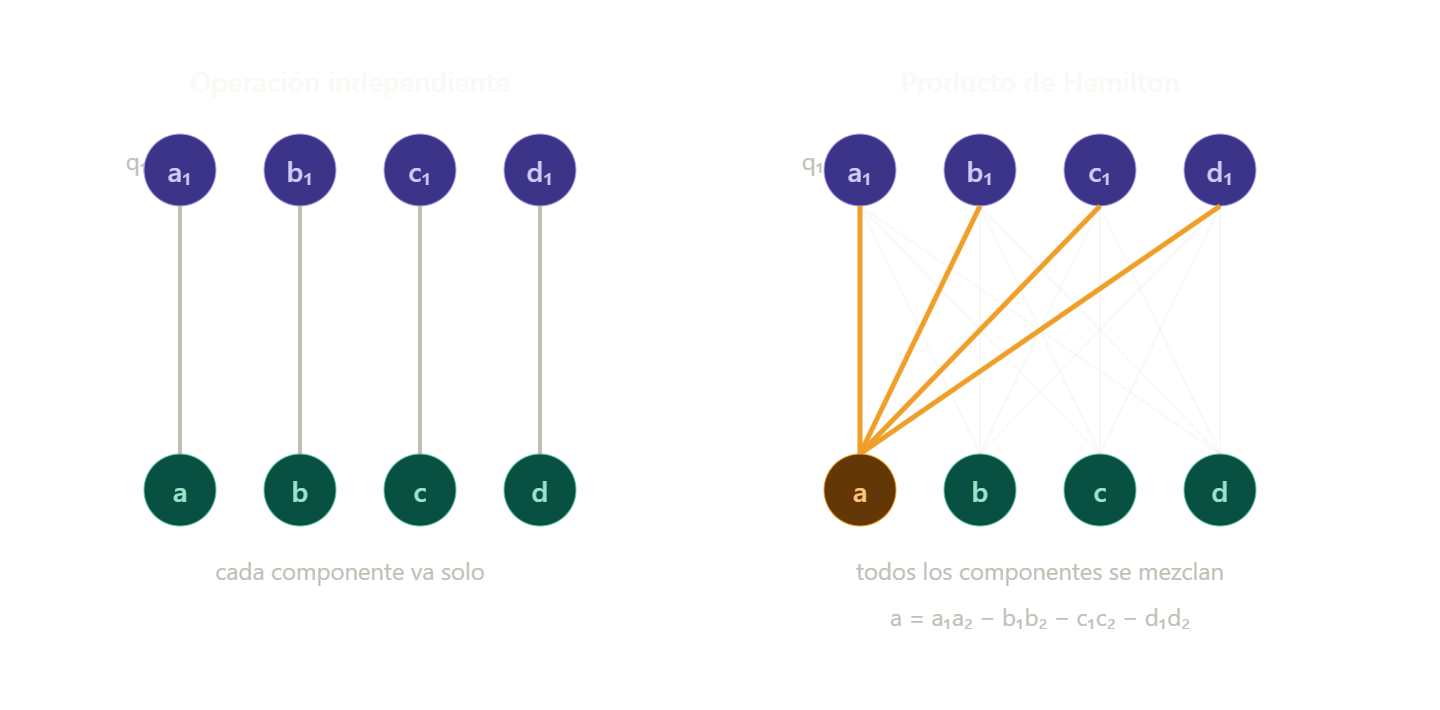

Pero si sólo nos quedamos con esa perspectiva podría parecer que entonces una multiplicación plonómica cualquiera podría funcionar igual. Y la respuesta a ese cuestionamiento es que además de conservar la relación entre variables porque cada elemento se multiplica por todos los demás, sucede algo interesante. Las reglas fundamentales de los cuaterniones además de afectar al signo de las sumas también afecta en que se produce algo llamado ***álgebra cerrada***.

El proceso mecánico es idéntico a multiplicar dos polinomios: primero propiedad distributiva, luego agrupar términos similares y sacar factor común. No hay magia ahí. La diferencia real está en las reglas de reducción. 

Supongamos que tenemos un producto de polinomios normal:

(a₁ + b₁x + c₁x² + d₁x³)(a₂ + b₂x + c₂x² + d₂x³)

El resultado de dicha multiplicación tiene términos x⁴, x⁵, x⁶... lo que significa que el resultado del producto vive en un espacio de 8 dimensiones. Algo similar sucedería si usamos diferentes variables y no solo "x", pues, la multiplicación produciría una variable con un exponente mayor al de los facotres originales.

Los términos x, x², x³ son bases independientes que no se "cancelan" entre sí porque x² simplemente es x², no hay ninguna regla que lo reduzca a otra cosa.

En cambio, con los cuaterniones q₁ × q₂:

Cuando aparece i², la regla i² = −1 lo convierte en un número real. Cuando aparece ij, la regla ij = k lo convierte en otro elemento de la base. Todas las combinaciones se reducen de vuelta al span de {1, i, j, k}. El resultado vive en 4 dimensiones, las mismas que las entradas.

Eso es **álgebra cerrada**. El producto de dos elementos siempre da un elemento del mismo espacio. Un polinomio no tiene eso.

Entonces, esta álgebra cerrada es la principal ventaja de los cuaterniones. Es muy útil en situaciones de geometría rotacional porque el producto Hamiltoniano tiene la ventaja de que un solo peso cuaterniático (4 parámetros) aplica exactamente una rotación+escala en 4D. Una capa densa equivalente necesitaría 16 pesos independientes sin ninguna garantía de preservar esa geometría.

Para este proyecto en concreto (representar peleadores de la UFC mediante cuaterniones) estas ventajas no brillan tanto, pues no se tratan datos geométricos. Aquí usaré cuaterniones más como una representación estructurada que dice "estos 4 stats son un solo perfil de combate", y no por sus propiedades geométricas profundas. 

El valor práctico de este trabajo está en la representación y en aprender cómo funcionan los cuaterniones, no en que vaya a superar dramáticamente a un modelo tabular estándar.

In [48]:
class Quaternion:

    # CONSTRUCCIÓN
    def __init__(self, a, b, c, d):
        """
        Crea un cuaternión  q = a + bi + cj + dk

        Parámetros
        ----------
        a : parte escalar  (real)
        b : coeficiente de i
        c : coeficiente de j
        d : coeficiente de k
        """
        self.a = float(a)
        self.b = float(b)
        self.c = float(c)
        self.d = float(d)

    # REPRESENTACIÓN LEGIBLE
    # __repr__ se llama automáticamente cuando se hace print(q) o se escribe q en la consola.
    def __repr__(self):
        def _term(val, symbol):
            sign = "+" if val >= 0 else "-"
            return f" {sign} {abs(val):.4g}{symbol}"
        return f"({self.a:.4g}{_term(self.b,'i')}{_term(self.c,'j')}{_term(self.d,'k')})"

    
    # SUMA Y RESTA  —  componente a componente, igual que los complejos
    # (a1+b1i+c1j+d1k) + (a2+b2i+c2j+d2k) = (a1+a2) + (b1+b2)i + ...
    def __add__(self, other):
        return Quaternion(self.a + other.a, self.b + other.b,
                          self.c + other.c, self.d + other.d)

    def __sub__(self, other):
        return Quaternion(self.a - other.a, self.b - other.b,
                          self.c - other.c, self.d - other.d)

    # Negación unaria: -q
    def __neg__(self):
        return Quaternion(-self.a, -self.b, -self.c, -self.d)


    # MULTIPLICACIÓN POR ESCALAR  (número real * cuaternión)
    def __rmul__(self, scalar):
        """Permite escribir  3 * q  (escalar a la izquierda)."""
        return Quaternion(scalar * self.a, scalar * self.b,
                          scalar * self.c, scalar * self.d)

    def __truediv__(self, scalar):
        """Permite escribir  q / 2."""
        return Quaternion(self.a / scalar, self.b / scalar,
                          self.c / scalar, self.d / scalar)

    
    # MULTIPLICACIÓN CUATERNIÁTICA  —  NO es conmutativa: p*q ≠ q*p
    def __mul__(self, other):
        # Si 'other' es un número real, delegar a __rmul__ del escalar
        if isinstance(other, (int, float)):
            return Quaternion(self.a * other, self.b * other,
                              self.c * other, self.d * other)

        a1, b1, c1, d1 = self.a, self.b, self.c, self.d
        a2, b2, c2, d2 = other.a, other.b, other.c, other.d

        return Quaternion(
            a1*a2 - b1*b2 - c1*c2 - d1*d2,   # parte real
            a1*b2 + b1*a2 + c1*d2 - d1*c2,   # coef. i
            a1*c2 - b1*d2 + c1*a2 + d1*b2,   # coef. j
            a1*d2 + b1*c2 - c1*b2 + d1*a2    # coef. k
        )

    # -------------------------------------------------------------------------
    # CONJUGADO, NORMA Y NORMALIZACIÓN
    def conjugate(self):
        """
        q* = a − bi − cj − dk
        Propiedad clave: q · q* = ||q||²  (siempre un número real positivo)
        """
        return Quaternion(self.a, -self.b, -self.c, -self.d)

    def norm(self):
        """
        ||q|| = sqrt(a² + b² + c² + d²)
        Es la "longitud" del cuaternión en ℝ⁴.
        """
        return (self.a**2 + self.b**2 + self.c**2 + self.d**2) ** 0.5

    def normalize(self):
        """
        Devuelve el cuaternión unitario:  q / ||q||
        Los cuaterniones unitarios (norma = 1) representan rotaciones 3D.
        """
        n = self.norm()
        if n == 0:
            raise ValueError("El cuaternión cero no se puede normalizar.")
        return self / n

    
    # INVERSO  —  q⁻¹ = q* / ||q||² | Útil porque q * q⁻¹ = 1  (cuaternión identidad)
    def inverse(self):
        n2 = self.norm() ** 2
        if n2 == 0:
            raise ValueError("El cuaternión cero no tiene inverso.")
        return self.conjugate() / n2


    # IGUALDAD (con tolerancia numérica para floats)
    def __eq__(self, other, tol=1e-9):
        return (abs(self.a - other.a) < tol and
                abs(self.b - other.b) < tol and
                abs(self.c - other.c) < tol and
                abs(self.d - other.d) < tol)

    
    # DESEMPAQUETADO  —  permite escribir  a, b, c, d = q
    def __iter__(self):
        return iter((self.a, self.b, self.c, self.d))




# =============================================================================
# TESTS

if __name__ == "__main__":

    print("= TEST 1 — Representación =")
    q = Quaternion(1, 2, -3, 4)
    print(f"  q = {q}")                          # (1 + 2i - 3j + 4k)


    print("\n= TEST 2 — Suma y resta =")
    p = Quaternion(1, 0,  2, -1)
    q = Quaternion(0, 1, -1,  3)
    print(f"  p     = {p}")
    print(f"  q     = {q}")
    print(f"  p + q = {p + q}")                  # (1 + 1i + 1j + 2k)
    print(f"  p - q = {p - q}")                  # (1 - 1i + 3j - 4k)


    print("\n= TEST 3 — Multiplicación  (verifica no-conmutatividad) =")
    i = Quaternion(0, 1, 0, 0)
    j = Quaternion(0, 0, 1, 0)
    k = Quaternion(0, 0, 0, 1)

    print(f"  i·j = {i * j}   → debe ser (0 + 0i + 0j + 1k) = k")
    print(f"  j·i = {j * i}   → debe ser (0 + 0i + 0j - 1k) = -k")
    print(f"  j·k = {j * k}   → debe ser i")
    print(f"  k·i = {k * i}   → debe ser j")
    print(f"  i·i = {i * i}   → debe ser -1  (0 - 1i + 0j + 0k = -1)")


    print("\n= TEST 4 — Conjugado y norma =")
    q = Quaternion(1, 2, 3, 4)
    print(f"  q      = {q}")
    print(f"  q*     = {q.conjugate()}")
    print(f"  ||q||  = {q.norm():.6f}   → debe ser sqrt(30) ≈ 5.477226")
    print(f"  q·q*   = {q * q.conjugate()}   → parte real = ||q||² = 30, resto = 0")


    print("\n= TEST 5 — Normalización =")
    q_unit = q.normalize()
    print(f"  q normalizado = {q_unit}")
    print(f"  norma         = {q_unit.norm():.10f}   → debe ser exactamente 1.0")


    print("\n= TEST 6 — Inverso  (q · q⁻¹ debe dar el cuaternión identidad) =")
    q     = Quaternion(1, 2, 3, 4)
    q_inv = q.inverse()
    identidad = q * q_inv
    print(f"  q⁻¹    = {q_inv}")
    print(f"  q·q⁻¹  = {identidad}   → debe ser (1 + 0i + 0j + 0k)")


    print("\n= TEST 7 — Desempaquetado =")
    q = Quaternion(1, 2, 3, 4)
    a, b, c, d = q
    print(f"  a={a}, b={b}, c={c}, d={d}")

= TEST 1 — Representación =
  q = (1 + 2i - 3j + 4k)

= TEST 2 — Suma y resta =
  p     = (1 + 0i + 2j - 1k)
  q     = (0 + 1i - 1j + 3k)
  p + q = (1 + 1i + 1j + 2k)
  p - q = (1 - 1i + 3j - 4k)

= TEST 3 — Multiplicación  (verifica no-conmutatividad) =
  i·j = (0 + 0i + 0j + 1k)   → debe ser (0 + 0i + 0j + 1k) = k
  j·i = (0 + 0i + 0j - 1k)   → debe ser (0 + 0i + 0j - 1k) = -k
  j·k = (0 + 1i + 0j + 0k)   → debe ser i
  k·i = (0 + 0i + 1j + 0k)   → debe ser j
  i·i = (-1 + 0i + 0j + 0k)   → debe ser -1  (0 - 1i + 0j + 0k = -1)

= TEST 4 — Conjugado y norma =
  q      = (1 + 2i + 3j + 4k)
  q*     = (1 - 2i - 3j - 4k)
  ||q||  = 5.477226   → debe ser sqrt(30) ≈ 5.477226
  q·q*   = (30 + 0i + 0j + 0k)   → parte real = ||q||² = 30, resto = 0

= TEST 5 — Normalización =
  q normalizado = (0.1826 + 0.3651i + 0.5477j + 0.7303k)
  norma         = 1.0000000000   → debe ser exactamente 1.0

= TEST 6 — Inverso  (q · q⁻¹ debe dar el cuaternión identidad) =
  q⁻¹    = (0.03333 - 0.06667i - 0.1j 

### Análisis Exploratorio de Datos (EDA)

Una vez desarrollado las operaciones aritméticas básicas para los cuaterniones podemos proceder a usar un dataset de la UFC para aplicar estos conceptos a un problema de ML.

Dataset: https://github.com/Greco1899/scrape_ufc_stats/tree/main 

Se usaron los archivos: 
- **ufc_fight_stats.csv:** stats por ronda, por peleador, por pelea
- **ufc_fight_results.csv:** resultados de cada pelea
- **ufc_fighter_tott.csv:** atributos físicos (talla, peso, alcance)

.

.

**GLOSARIO DE VARIABLES POR DATASET:**

**fight_stats** — columnas por ronda:
- FIGHTER, BOUT, ROUND, KD (knockdowns)
- SIG.STR.  → formato "X of Y" (golpes significativos aterrizados / intentados)
- TD        → formato "X of Y" (derribos aterrizados / intentados)
- SIG.STR.% → porcentaje como string "61%" o "---" si 0 intentos
- TD%       → porcentaje como string, "---" si 0 intentos (~46% de filas)
- CTRL      → tiempo de control en formato "MM:SS"
- HEAD, BODY, LEG, DISTANCE, CLINCH, GROUND → desglose de golpes

fight_results — una fila por pelea:
- BOUT, EVENT, OUTCOME (W/L), WEIGHTCLASS, METHOD, ROUND, TIME
- ROUND → ronda en que terminó la pelea
- TIME  → tiempo dentro de esa ronda ("4:37")

In [49]:
#EXPLORACIÓN DEL DATASET

import pandas as pd

stats = pd.read_csv("1 ufc_fight_stats.csv")
results = pd.read_csv("1 ufc_fight_results.csv")
tott = pd.read_csv("1 ufc_fighter_tott.csv")

In [50]:
stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 40998 entries, 0 to 40997
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EVENT       40998 non-null  str    
 1   BOUT        40998 non-null  str    
 2   ROUND       40956 non-null  str    
 3   FIGHTER     40956 non-null  str    
 4   KD          40956 non-null  float64
 5   SIG.STR.    40956 non-null  str    
 6   SIG.STR. %  40956 non-null  str    
 7   TOTAL STR.  40956 non-null  str    
 8   TD          40956 non-null  str    
 9   TD %        40956 non-null  str    
 10  SUB.ATT     40956 non-null  float64
 11  REV.        40956 non-null  float64
 12  CTRL        40956 non-null  str    
 13  HEAD        40956 non-null  str    
 14  BODY        40956 non-null  str    
 15  LEG         40956 non-null  str    
 16  DISTANCE    40956 non-null  str    
 17  CLINCH      40956 non-null  str    
 18  GROUND      40956 non-null  str    
dtypes: float64(3), str(16)
memory usage:

In [51]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 8701 entries, 0 to 8700
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   EVENT        8701 non-null   str  
 1   BOUT         8701 non-null   str  
 2   OUTCOME      8701 non-null   str  
 3   WEIGHTCLASS  8701 non-null   str  
 4   METHOD       8701 non-null   str  
 5   ROUND        8701 non-null   int64
 6   TIME         8701 non-null   str  
 7   TIME FORMAT  8701 non-null   str  
 8   REFEREE      8675 non-null   str  
 9   DETAILS      8623 non-null   str  
 10  URL          8701 non-null   str  
dtypes: int64(1), str(10)
memory usage: 747.9 KB


In [52]:
tott.info()

<class 'pandas.DataFrame'>
RangeIndex: 4496 entries, 0 to 4495
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   FIGHTER  4496 non-null   str  
 1   HEIGHT   4496 non-null   str  
 2   WEIGHT   4496 non-null   str  
 3   REACH    4496 non-null   str  
 4   STANCE   3586 non-null   str  
 5   DOB      4496 non-null   str  
 6   URL      4496 non-null   str  
dtypes: str(7)
memory usage: 246.0 KB


In [53]:
#.shape devuelve las dimensiones del DataFrame en forma de una tupla

#Por ejemplo: (3560, 12)
#3560 filas (observaciones)
#12 columnas (variables)

print(stats.shape)

(40998, 19)


In [54]:
#CONTEO DE NULOS POR COLUMNA (ambas versiones son equivalentes)
print(stats.isna().sum())
print("\n----------\n")
print(stats.isnull().sum())

#PORCENTAJE DE NULOS POR COLUMNA
print("\n----------\n")
print((stats.isna().mean() * 100).round(2))

EVENT          0
BOUT           0
ROUND         42
FIGHTER       42
KD            42
SIG.STR.      42
SIG.STR. %    42
TOTAL STR.    42
TD            42
TD %          42
SUB.ATT       42
REV.          42
CTRL          42
HEAD          42
BODY          42
LEG           42
DISTANCE      42
CLINCH        42
GROUND        42
dtype: int64

----------

EVENT          0
BOUT           0
ROUND         42
FIGHTER       42
KD            42
SIG.STR.      42
SIG.STR. %    42
TOTAL STR.    42
TD            42
TD %          42
SUB.ATT       42
REV.          42
CTRL          42
HEAD          42
BODY          42
LEG           42
DISTANCE      42
CLINCH        42
GROUND        42
dtype: int64

----------

EVENT         0.0
BOUT          0.0
ROUND         0.1
FIGHTER       0.1
KD            0.1
SIG.STR.      0.1
SIG.STR. %    0.1
TOTAL STR.    0.1
TD            0.1
TD %          0.1
SUB.ATT       0.1
REV.          0.1
CTRL          0.1
HEAD          0.1
BODY          0.1
LEG           0.1
DISTANCE      

In [55]:
#RESUMEN TABULAR DE DATOS NULOS
nulls = pd.DataFrame({
    'Nulos': stats.isna().sum(),
    'Porcentaje': (stats.isna().mean() * 100).round(2)
})

nulls.sort_values('Porcentaje', ascending=False)

,Nulos,Porcentaje
ROUND,42,0.1
KD,42,0.1
FIGHTER,42,0.1
REV.,42,0.1
CTRL,42,0.1
SIG.STR.,42,0.1
SIG.STR. %,42,0.1
TOTAL STR.,42,0.1
TD,42,0.1
TD %,42,0.1


### Procesamiento de datos

**Limpieza de datos mínima**

Eliminamos los datos nulos y reorganizamos los índices luego de eso.

In [56]:
# - ELIMINAR FILAS NULAS -
#dropna(subset=['FIGHTER']) Elimina todas las filas donde la columna FIGHTER sea NaN
#reset_index(drop=True) Reorganiza los índices para que vuelvan a ser consecutivos

stats   = stats.dropna(subset=['FIGHTER']).reset_index(drop=True)
results = results.dropna(subset=['BOUT']).reset_index(drop=True)

In [57]:
print(f"fight_stats:   {len(stats):>6,} filas, {stats['FIGHTER'].nunique():,} peleadores")
print(f"fight_results: {len(results):>6,} filas, {results['BOUT'].nunique():,} bouts")
print(f"fighter_tott:  {len(tott):>6,} filas")

fight_stats:   40,956 filas, 2,678 peleadores
fight_results:  8,701 filas, 8,566 bouts
fighter_tott:   4,496 filas


Para el cuaternión de carrera necesitamos calcular:
- SLpM    = golpes_sig_aterrizados / minutos_totales
- TDAvg   = derribos_aterrizados / (minutos_totales / 15)
- StrDef  = 1 - (golpes_sig_rival / golpes_sig_rival_intentados)
- TDDef   = 1 - (derribos_rival / derribos_rival_intentados)

In [58]:
#Calcular la duración de la pelea
def parse_time_min(t):
    """4:37 -> 4.617 minutos"""
    try:
        m, s = str(t).strip().split(':')
        return int(m) + int(s) / 60
    except:
        return 5.0

results['total_min'] = (results['ROUND'] - 1) * 5 + results['TIME'].apply(parse_time_min)

Algunas equivalencias entre R y Python sobre el EDA:

In [59]:
#Estructura general | R: str(df)  /  dim(df)  /  colnames(df)

for nombre, df in [("fight_stats", stats), ("fight_results", results), ("fighter_tott", tott)]:
    print(f"\n - {nombre} -")
    print(f"\nForma (filas x cols): {df.shape}") #R: dim(f)
    print(f"\nColumnas: {df.columns.tolist()}")  #R: colnames(df)
    print(f"\nTipos:\n{df.dtypes.to_string()}")  #R: str(df) / sapply(df, class)


 - fight_stats -

Forma (filas x cols): (40956, 19)

Columnas: ['EVENT', 'BOUT', 'ROUND', 'FIGHTER', 'KD', 'SIG.STR.', 'SIG.STR. %', 'TOTAL STR.', 'TD', 'TD %', 'SUB.ATT', 'REV.', 'CTRL', 'HEAD', 'BODY', 'LEG', 'DISTANCE', 'CLINCH', 'GROUND']

Tipos:
EVENT             str
BOUT              str
ROUND             str
FIGHTER           str
KD            float64
SIG.STR.          str
SIG.STR. %        str
TOTAL STR.        str
TD                str
TD %              str
SUB.ATT       float64
REV.          float64
CTRL              str
HEAD              str
BODY              str
LEG               str
DISTANCE          str
CLINCH            str
GROUND            str

 - fight_results -

Forma (filas x cols): (8701, 12)

Columnas: ['EVENT', 'BOUT', 'OUTCOME', 'WEIGHTCLASS', 'METHOD', 'ROUND', 'TIME', 'TIME FORMAT', 'REFEREE', 'DETAILS', 'URL', 'total_min']

Tipos:
EVENT              str
BOUT               str
OUTCOME            str
WEIGHTCLASS        str
METHOD             str
ROUND         

In [60]:
# VALORES FALTANTES v.2 | R: colSums(is.na(df))
for nombre, df in [("fight_stats", stats), ("fight_results", results), ("fighter_tott", tott)]:
    nulos = df.isnull().sum()                              # R: colSums(is.na(df))
    pct   = df.isnull().mean() * 100                       # R: colMeans(is.na(df)) * 100
    resumen = pd.DataFrame({'nulos': nulos, 'porcentaje': pct})
    resumen = resumen[resumen['nulos'] > 0]
    print(f"\n── {nombre} ──")
    if resumen.empty:
        print("  Sin valores faltantes.")
    else:
        print(resumen.to_string())


# Valores "---" en fight_stats (no son NaN sino string centinela)
print("\n── Valores '---' en fight_stats (intentos = 0, no son NaN) ──")
for col in ['SIG.STR. %', 'TD %']:
    n   = (stats[col] == '---').sum()
    pct = n / len(stats) * 100
    print(f"  {col:<15}: {n:>6,} filas ({pct:.1f}%)")


── fight_stats ──
  Sin valores faltantes.

── fight_results ──
         nulos  porcentaje
REFEREE     26    0.298816
DETAILS     78    0.896449

── fighter_tott ──
        nulos  porcentaje
STANCE    910   20.240214

── Valores '---' en fight_stats (intentos = 0, no son NaN) ──
  SIG.STR. %     :    207 filas (0.5%)
  TD %           : 19,049 filas (46.5%)


In [61]:
# ESTADÍSTICAS DESCRIPTIVAS - cols numéricas
# R: summary(df) = Python: df.describe()

print(results[['ROUND', 'total_min']].describe().round(2).to_string())

         ROUND  total_min
count  8701.00    8701.00
mean      2.36      10.59
std       1.02       6.06
min       1.00       0.08
25%       1.00       4.65
50%       3.00      13.55
75%       3.00      15.00
max       5.00      25.00


In [62]:
# DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS - fight_results
# R: table(df$col), prop.table(table(df$col))

columnas_cat = ['METHOD', 'WEIGHTCLASS', 'ROUND']

for col in columnas_cat:
    print(f"\n - {col} -")
    # .str.strip() solo aplica a columnas de texto; ROUND es int, no lo necesita
    serie = results[col].str.strip() if results[col].dtype == object else results[col]
    conteo = serie.value_counts()                  # R: table(df$col)
    propor = serie.value_counts(normalize = True)  # R: prop.table(...)

for cat in conteo.index[:8]:
    print(f" {str(cat):<32} {conteo[cat]:>5} ({propor[cat] * 100:5.1f})")


 - METHOD -

 - WEIGHTCLASS -

 - ROUND -
 3                                 4433 ( 50.9)
 1                                 2442 ( 28.1)
 2                                 1440 ( 16.5)
 5                                  336 (  3.9)
 4                                   50 (  0.6)


In [63]:
# DISTRIBUCIÓN DE DURACIÓN DE PELEA

#Cuartiles | R: quantile(x, probs=c(0, 0.25, 0.5, 0.75, 1))
cuartiles = results['total_min'].quantile([0, 0.25, 0.5, 0.75, 1.0])
print("\nCuartiles")

for q, v in cuartiles.items():
    print(f" Q{int(q * 100):>3}% : {v:.2f} min")

#DISTRIBUCIÓN POR MÉTODO
print("\nDuración media por método de victoria:")

media_por_método = (
    results.groupby(results['METHOD'].str.strip())['total_min']
    .mean()    # R: tapply / group_by + summarise
    .sort_values(ascending = False)
    .round(2)
)
print(media_por_método.head(6).to_string())


Cuartiles
 Q  0% : 0.08 min
 Q 25% : 4.65 min
 Q 50% : 13.55 min
 Q 75% : 15.00 min
 Q100% : 25.00 min

Duración media por método de victoria:
METHOD
Decision - Majority        15.82
Decision - Unanimous       15.71
Decision - Split           15.61
Overturned                  9.24
Other                       9.00
TKO - Doctor's Stoppage     8.53


In [64]:
# STATS DE COMBATE - fight_stats

cols_num = ['KD', 'SUB.ATT', 'REV.']
print(stats[cols_num].describe().round(3).to_string())

print(f"\nKnockdowns > 0 en {(stats['KD'] > 0).sum():,} rondas "
      f"({(stats['KD'] > 0).mean()*100:.1f}% del total)")
 
print(f"\nRondas con al menos 1 intento de derribo: "
      f"{(stats['TD'] != '0 of 0').sum():,}")

              KD    SUB.ATT       REV.
count  40956.000  40956.000  40956.000
mean       0.091      0.158      0.057
std        0.318      0.475      0.246
min        0.000      0.000      0.000
25%        0.000      0.000      0.000
50%        0.000      0.000      0.000
75%        0.000      0.000      0.000
max        5.000      8.000      4.000

Knockdowns > 0 en 3,387 rondas (8.3% del total)

Rondas con al menos 1 intento de derribo: 21,907


In [65]:
# TOP PELEADORES

# R: aggregate(BOUT ~ FIGHTER, data=stats, FUN=function(x) length(unique(x)))
# o con dplyr: group_by(FIGHTER) %>% summarise(peleas = n_distinct(BOUT))

peleas_por_luchador = (
    stats.groupby('FIGHTER')['BOUT']
    .nunique()
    .sort_values(ascending = False)
)

print("\nTop 12 con más peleas registradas:")
print(peleas_por_luchador.head(12).to_string())

#Versión 1
print("\nPeleas de figuras conocidas:")
for nombre in ['Khabib Nurmagomedov', 'Israel Adesanya',
               'Jon Jones', 'Conor McGregor', 'Amanda Nunes']:
    n = peleas_por_luchador.get(nombre, 0)
    print(f"  {nombre:<25} {n:>3}")


Top 12 con más peleas registradas:
FIGHTER
Jim Miller          46
Andrei Arlovski     41
Donald Cerrone      37
Clay Guida          37
Neil Magny          37
Rafael Dos Anjos    36
Jeremy Stephens     35
Demian Maia         33
Charles Oliveira    33
Diego Sanchez       32
Michael Johnson     32
Edson Barboza       31

Peleas de figuras conocidas:
  Khabib Nurmagomedov        13
  Israel Adesanya            18
  Jon Jones                  23
  Conor McGregor             12
  Amanda Nunes               16


In [66]:
#Vista de peleadores conocidos v.2
print("\n - Peleas registradas de figuras conocidas -")
bount_count = stats.groupby('FIGHTER')['BOUT'].nunique()

for name in ['Khabib Nurmagomedov','Israel Adesanya','Jon Jones','Conor McGregor',
             'Amanda Nunes','Georges St-Pierre']:
    n = bount_count.get(name, 0)
    print(f" {name:<25} {n:>3} peleas")


 - Peleas registradas de figuras conocidas -
 Khabib Nurmagomedov        13 peleas
 Israel Adesanya            18 peleas
 Jon Jones                  23 peleas
 Conor McGregor             12 peleas
 Amanda Nunes               16 peleas
 Georges St-Pierre          19 peleas


In [67]:
# PESOS Y FÍSICO - fighter_tott
# R: table(tott$STANCE)

print("\nDistribución de postura (stance):")
print(tott['STANCE'].value_counts().to_string()) # R: table(tott$STANCE)

# Pesos más comunes
print("\nDivisiones de peso más comunes:")
print(tott['WEIGHT'].value_counts().head(8).to_string())
 
# Valores faltantes físicos
print("\nValores '--' en columnas físicas (no son NaN, son strings):")
for col in ['HEIGHT', 'REACH']:
    n = (tott[col] == '--').sum()
    print(f"  {col}: {n} ({n/len(tott)*100:.1f}%)")


Distribución de postura (stance):
STANCE
Orthodox       2752
Southpaw        606
Switch          218
Open Stance       7
Sideways          3

Divisiones de peso más comunes:
WEIGHT
155 lbs.    658
170 lbs.    639
185 lbs.    551
135 lbs.    514
145 lbs.    501
205 lbs.    386
125 lbs.    339
115 lbs.    143

Valores '--' en columnas físicas (no son NaN, son strings):
  HEIGHT: 395 (8.8%)
  REACH: 2017 (44.9%)


In [68]:
#Distribución de métodos de victoria
print("\n - Cómo terminan las peleas -")
total = len(results)

for m, n in results['METHOD'].str.strip().value_counts().head(5).items():
    print(f" {m:<32} {n:>5} ({n / total * 100: 4.1f})")

print("\nDatos listos")


 - Cómo terminan las peleas -
 Decision - Unanimous              3135 ( 36.0)
 KO/TKO                            2739 ( 31.5)
 Submission                        1685 ( 19.4)
 Decision - Split                   825 ( 9.5)
 Decision - Majority                104 ( 1.2)

Datos listos


AGREGAR INTERPRETACIÓN DE LOS RESULTADOS DEL EDA JIJIJA

### Construir cuaterniones de carrera por peleador

Bien, ahora pasemos a lo que vinimos, representemos a diferentes peleadores de la UFC mediante cuaterniones.

Los cuaterniones en cuestión serán de la forma:

q = SLpM + TDAvg·i + StrDef·j + TDDef·k

Donde:
- SLpM   = golpes significativos aterrizados por minuto   (ofensiva de pie)
- TDAvg  = derribos cada 15 minutos                       (ofensiva de suelo)
- StrDef = % de golpes del rival que NO aterrizan         (defensa de pie)
- TDDef  = % de derribos del rival que NO aterrizan       (defensa de suelo)

**Parsear columnas**

Cada celda de SIG.STR. dice algo como "23 of 38":

O sea:

23 = golpes que aterrizaron
   
38 = golpes que intentó

.apply(lambda ...) es como sapply/lapply en R, aplica una función
a cada elemento de la columna.

lambda s: ...  es una función anónima, equivale a function(s) en R.

In [69]:
# PARSEAR "X of Y" -> ENTEROS
stats['SIG_LAND'] = stats['SIG.STR.'].apply(lambda s: int(str(s).split(' of ')[0]))
stats['SIG_ATT'] = stats['SIG.STR.'].apply(lambda s: int(str(s).split(' of ')[1]))

stats['TD_LAND'] = stats['TD'].apply(lambda s: int(str(s).split(' of ')[0]))
stats['TD_ATT'] = stats['TD'].apply(lambda s: int(str(s).split(' of ')[1]))

print("Columnas parseadas :)\n")
print(stats[['FIGHTER','SIG.STR.','SIG_LAND','SIG_ATT','TD','TD_LAND','TD_ATT']].head(3).to_string())

Columnas parseadas :)

        FIGHTER  SIG.STR.  SIG_LAND  SIG_ATT      TD  TD_LAND  TD_ATT
0  Arnold Allen    9 of 9         9        9  2 of 2        2       2
1  Arnold Allen  23 of 38        23       38  0 of 0        0       0
2  Arnold Allen  32 of 52        32       52  0 of 0        0       0


**STATS DEL RIVAL POR RONDA**

Cada BOUT + ROUND tiene exactamente 2 filas por peleador.

rival = suma_del_grupo - yo_mismo

.transform('sum') calcula la suma del grupo pero la DEVUELVE
para cada fila (sin reducir), como dplyr::mutate(tot = sum(x)).
Contrasta con .agg('sum') que sí reduce (como dplyr::summarise).

In [70]:
# STATS DEL RIVAL POR RONDA (usando transform)

for col in ['SIG_LAND', 'SIG_ATT', 'TD_LAND', 'TD_ATT']:
    total_grupo = stats.groupby(['BOUT', 'ROUND'])[col].transform('sum')
    stats[f"OPP_{col}"] = total_grupo - stats[col]

#Verificación: Round 1 de Allen vs Costa
bout_eg = 'Arnold Allen vs. Melquizael Costa'
cols_eg = ['FIGHTER','SIG_LAND','OPP_SIG_LAND','OPP_SIG_ATT','TD_LAND','OPP_TD_LAND','OPP_TD_ATT']
print(stats[stats['BOUT'] == bout_eg][cols_eg].head(2).to_string())

        FIGHTER  SIG_LAND  OPP_SIG_LAND  OPP_SIG_ATT  TD_LAND  OPP_TD_LAND  OPP_TD_ATT
0  Arnold Allen         9            10           14        2            0           2
1  Arnold Allen        23            26           78        0            0           0


**Agregar a nivel de pelea (por pelea)**

1. Primero sumamos las rondas dentro de cada pelea.
2. Luego unimos la duración total de la pelea (total_min).

.groupby().agg(nueva_col=('col_original','función')) es la sintaxis moderna de pandas (desde v0.25).

Equivalente en R:

group_by(FIGHTER, BOUT) |> summarise(sig_land = sum(SIG_LAND), ...)

In [71]:
per_fight = (
    stats.groupby(['FIGHTER', 'BOUT']).agg(
        sig_land     = ('SIG_LAND',      'sum'),
        td_land      = ('TD_LAND',       'sum'),
        opp_sig_land = ('OPP_SIG_LAND',  'sum'),
        opp_sig_att  = ('OPP_SIG_ATT',   'sum'),
        opp_td_land  = ('OPP_TD_LAND',   'sum'),
        opp_td_att   = ('OPP_TD_ATT',    'sum'),
    )
    .reset_index() #convierte los índices del groupby de vuelta a columnas
)

#Unir duración de pelea desde results
per_fight = per_fight.merge(results[['BOUT', 'total_min']].drop_duplicates('BOUT'), 
                            on = 'BOUT',
                            how = 'left'
                           )

print(f"\nNivel pelea: {len(per_fight):,} filas | {per_fight['FIGHTER'].nunique():,} peleadores")


Nivel pelea: 17,090 filas | 2,678 peleadores


**AGREGAR A NIVEL DE CARRERA (FIGHTER)**

Ahora sumamos todas las peleas de cada peleador. total_min se suma correctamente porque ya está a nivel de pelea (no se repite por ronda).

In [72]:
career = (per_fight.groupby('FIGHTER').agg(
    fights             = ('BOUT',          'count'),
    total_sig_land     = ('sig_land',       'sum'),
    total_td_land      = ('td_land',        'sum'),
    total_min          = ('total_min',      'sum'),
    total_opp_sig_land = ('opp_sig_land',   'sum'),
    total_opp_sig_att  = ('opp_sig_att',    'sum'),
    total_opp_td_land  = ('opp_td_land',    'sum'),
    total_opp_td_att   = ('opp_td_att',     'sum'),)
    .reset_index())

print(f"Nivel carrera: {len(career):,} peleadores")

Nivel carrera: 2,678 peleadores


**CALCULAR LAS 4 MÉTRICAS**

Para StrDef y TDDef: si el denominador es 0 (rival nunca intentó nada), no hay información → asignamos defensa perfecta (1.0).

.apply(lambda row: ..., axis=1) recorre el df fila por fila

(axis=1 = fila; axis=0 = columna — al revés de lo que parece intuitivo)

In [73]:
#CALCULAR LAS 4 MÉTRICAS DEL CUATERNIÓN

career['SLpM'] = career['total_sig_land'] / career['total_min']
career['TDAvg'] = career['total_td_land'] / career['total_min'] * 15 # AQUÍ ES DONDE SE CALCULAN LOS Take Downs por cada 15 min.

#Defensa de striking
career['StrDef'] = career.apply(
    lambda r: 1.0 - r['total_opp_sig_land'] / r['total_opp_sig_att']
        if r['total_opp_sig_att'] > 0 else 1.0,
    axis = 1)

#Defensa de derribos
career['TDDef'] = career.apply(
    lambda r: 1.0 - r['total_opp_td_land'] / r['total_opp_td_att']
        if r['total_opp_td_att'] > 0 else 1.0,
    axis = 1)

#Filtrar: peleadores con < 3 peleas tienen stats demasiado ruidosas
career = career[career['fights'] >= 3].reset_index(drop = True)

print(f"Métricas calculadas | {len(career):,} peleadores (filtro ≥ 3 peleas)")

#Resumen de las 4 métricas
print("\nDistribución de las 4 métricas (toda la carrera):")
print(career[['SLpM','TDAvg','StrDef','TDDef']].describe().round(3).to_string())

Métricas calculadas | 1,849 peleadores (filtro ≥ 3 peleas)

Distribución de las 4 métricas (toda la carrera):
           SLpM     TDAvg    StrDef     TDDef
count  1849.000  1849.000  1849.000  1849.000
mean      3.411     1.540     0.537     0.599
std       1.394     1.329     0.079     0.222
min       0.115     0.000     0.087     0.000
25%       2.413     0.558     0.493     0.471
50%       3.283     1.200     0.543     0.625
75%       4.251     2.239     0.589     0.750
max      11.004     8.927     0.833     1.000


**CONSTRUIR EL CUATERNIÓN DE CADA PELEADOR**

q = SLpM + TDAvg·i + StrDef·j + TDDef·k

career.apply(..., axis=1) aplica una función a cada fila.

La función recibe la fila como un objeto tipo *dict* y devuelve el cuaternión construido con nuestros 4 valores.

In [74]:
career['quaternion'] = career.apply(
    lambda r: Quaternion(r['SLpM'], r['TDAvg'], r['StrDef'], r['TDDef']),
    axis = 1
)

career['q_norm'] = career['quaternion'].apply(lambda q: q.norm())

In [75]:
#INSPECCIÓN DE PELEADORES CONOCIDOS

nombres = [
    'Khabib Nurmagomedov', 'Israel Adesanya', 'Jon Jones',
    'Conor McGregor',      'Kamaru Usman',    'Francis Ngannou',
    'Amanda Nunes',        'Charles Oliveira','Georges St-Pierre',
    'Dustin Poirier',      'Max Holloway',    'Alex Pereira',
]

print(f"{'PELEADOR':<26} {'Peleas':>6}  {'SLpM':>6} {'TDAvg':>6} {'StrDef':>7} {'TDDef':>7}  {'||q||':>7}")

for nombre in nombres:
    fila = career[career['FIGHTER'] == nombre]
    if not fila.empty:
        r = fila.iloc[0]
        print(f"{nombre:<26} {int(r['fights']):>6}  "
              f"{r['SLpM']:>6.2f} {r['TDAvg']:>6.2f} "
              f"{r['StrDef']:>7.3f} {r['TDDef']:>7.3f}  {r['q_norm']:>7.4f}")

PELEADOR                   Peleas    SLpM  TDAvg  StrDef   TDDef    ||q||
Khabib Nurmagomedov            13    4.10   5.32   0.654   0.846   6.8035
Israel Adesanya                18    4.22   0.05   0.565   0.756   4.3291
Jon Jones                      23    4.71   2.03   0.620   0.926   5.2535
Conor McGregor                 12    5.80   0.73   0.527   0.615   5.9026
Kamaru Usman                   16    5.13   3.44   0.545   0.787   6.2539
Francis Ngannou                13    3.13   1.02   0.455   0.680   3.3920
Amanda Nunes                   16    5.00   3.07   0.589   0.711   5.9443
Charles Oliveira               33    3.42   2.42   0.469   0.568   4.2488
Georges St-Pierre              19    4.29   4.41   0.673   0.725   6.2300
Dustin Poirier                 27    6.43   1.45   0.526   0.658   6.6478
Max Holloway                   29    7.65   0.25   0.571   0.811   7.7197
Alex Pereira                   12    5.16   0.11   0.539   0.791   5.2505


**NOTAS:**

- *Sobre por qué TDAvg es cada 15 min. y no por minuto...*

Es una convención de ufcstats.com, no una decisión nuestra. Los derribos son eventos poco frecuentes — incluso Khabib, el mejor grappler de la historia, promedia 5.32 derribos cada 15 minutos, lo que serían solo ~0.35 por minuto. Expresarlo por minuto daría decimales pequeños y poco intuitivos. 15 minutos es la duración de una pelea de 3 rounds, así que el número se lee como "derribos por pelea estándar", lo cual tiene sentido práctico.
  
- *A qué nos referimos con que lambda s es una función anónima...*

Una función normal en Python tiene nombre y se define con def. Una lambda es lo mismo pero sin nombre, escrita en una sola línea para usar en el momento y descartar.

- *Sobre qué significa tott...*

*Tale of the Tape*, es una expresión del boxeo que viene de cuando los reporteros medían físicamente a los peleadores antes del combate con una cinta métrica (tape) y publicaban esa comparación lado a lado. Hoy en MMA sigue usándose para referirse a la ficha física de un peleador: talla, peso, alcance y postura de guardia. Por eso el archivo solo tenía esas columnas y no stats de rendimiento.

- *Sobre qué significa BOUT...*

En deportes de combate, un *bout* es simplemente una pelea formal entre dos atletas. Viene del inglés y es más específico que "fight" — implica un encuentro oficial, programado y reglamentado. En el contexto del dataset es el identificador de cada pelea individual, en formato "Peleador1 vs. Peleador2".

- *En la inspección de peleadores, ¿Qué significa ||q||?...*

Como se explicó más arriba, es la notación matemática estándar para la norma de un vector o cuaternión. Su "longitud" en el espacio de 4 dimensiones, calculada como √(a² + b² + c² + d²). 

En el contexto del proyecto, representa la magnitud del perfil de combate combinado: un ||q|| alto significa que el peleador es extremo en al menos alguna dimensión. Max Holloway tenía el más alto porque su SLpM domina el cálculo; Khabib lo tiene alto por su TDAvg. Es importante recordar que antes de normalizar, ||q|| está sesgado hacia SLpM simplemente porque esa métrica vive en una escala más grande que StrDef o TDDef.

### Ploteos (visualizaciones)

Bueno, ahora grafiquemos un poco para observar qué nos dicen los datos estructurados como cuaterniones.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import gaussian_kde

In [77]:
metrics = ['SLpM', 'TDAvg', 'StrDef', 'TDDef']

#Similar a la lista 'nombres' pero aquí hacemos uso de un diccionario
destacados = {
    'Khabib Nurmagomedov': 'Khabib',
    'Israel Adesanya':     'Adesanya',
    'Jon Jones':           'Jones',
    'Conor McGregor':      'McGregor',
    'Kamaru Usman':        'Usman',
    'Georges St-Pierre':   'GSP',
    'Max Holloway':        'Holloway',
    'Charles Oliveira':    'Oliveira',
    'Francis Ngannou':     'Ngannou',
    'Amanda Nunes':        'Nunes',
    'Dustin Poirier':      'Poirier',
    'Alex Pereira':        'Pereira',
}

**NORMALIZACIÓN (min-max, rango [0,1])**

El problema: SLpM vive en escala 0–11, mientras que StrDef/TDDef en 0–1. Sin normalizar, las distancias y el radar estarían dominados por SLpM.

Min-Max:  

$$ x_n = (x - min) / (max - min) $$

Tal que n = norm

R equivalente: (x - min(x)) / (max(x) - min(x))

Usamos sklearn solo para no re-escribir esto a mano, pero la operación es aritmética simple.

In [78]:
#from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
vals_norm = scaler.fit_transform(career[metrics]) # devuelve un array numpy
career_norm = career.copy()
career_norm[metrics] = vals_norm

print("Rango original vs normalizado")
for m in metrics:
    orig = f"{career[m].min():.2f} - {career[m].max():.2f}"
    norm = f"{career_norm[m].min():.2f} - {career_norm[m].max():.2f}"
    print(f" {m:<8}: original [{orig}] --> normalizado [{norm}]")

Rango original vs normalizado
 SLpM    : original [0.11 - 11.00] --> normalizado [0.00 - 1.00]
 TDAvg   : original [0.00 - 8.93] --> normalizado [0.00 - 1.00]
 StrDef  : original [0.09 - 0.83] --> normalizado [0.00 - 1.00]
 TDDef   : original [0.00 - 1.00] --> normalizado [0.00 - 1.00]


**PLOT 1**

Distribución de las 4 métricas.

(valores originales, sin normalizar — más interpretables)

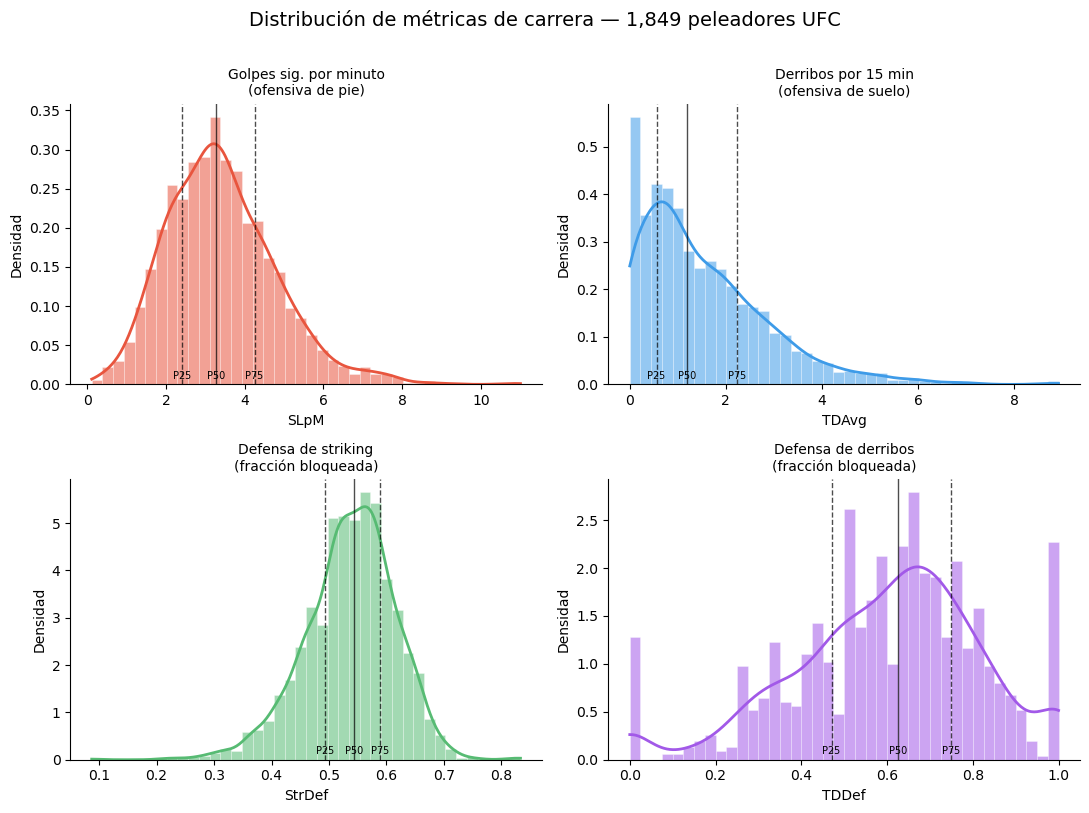

In [79]:
etiquetas = {
    'SLpM':   'Golpes sig. por minuto\n(ofensiva de pie)',
    'TDAvg':  'Derribos por 15 min\n(ofensiva de suelo)',
    'StrDef': 'Defensa de striking\n(fracción bloqueada)',
    'TDDef':  'Defensa de derribos\n(fracción bloqueada)',
}
colores = ['#E8553E', '#3E9BE8', '#57BB73', '#A259E8']

fig, axes = plt.subplots(2, 2, figsize = (11, 8))
fig.suptitle('Distribución de métricas de carrera — 1,849 peleadores UFC', fontsize=14, y=1.01)

for ax, metric, color in zip(axes.flat, metrics, colores):
    data = career[metric]

    #Histograma + línea de densidad
    ax.hist(data, bins=40, color=color, alpha=0.55, density=True, edgecolor='white', linewidth=0.4)

    #Línea KDE manual con scipy (R: density())
    #from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 300)
    ax.plot(xs, kde(xs), color=color, linewidth=2)

    #Líneas de percentiles
    p25, p50, p75 = data.quantile([0.25,0.5,0.75])
    for p, ls, lbl in [(p25, '--', 'P25'), (p50, '-', 'P50'), (p75, '--', 'P75')]:
        ax.axvline(p, color='black', linestyle=ls, linewidth=1, alpha=0.7)
        ax.text(p, ax.get_ylim()[1] * 0.02, lbl, ha='center', fontsize=7, color='black')

    ax.set_title(etiquetas[metric], fontsize=10)
    ax.set_xlabel(metric)
    ax.set_ylabel('Densidad')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
#plt.savefig("plots/01_distribuciones.png", dpi=150, bbox_inches='tight')
#plt.close()
#print("\nPlot 1 guardado: plots/01_distribuciones.png")

**PLOT 2**

Scatter plot: ofensiva de pie vs ofensiva de suelo.

Se busca revelar los estilos de pelea dominantes.

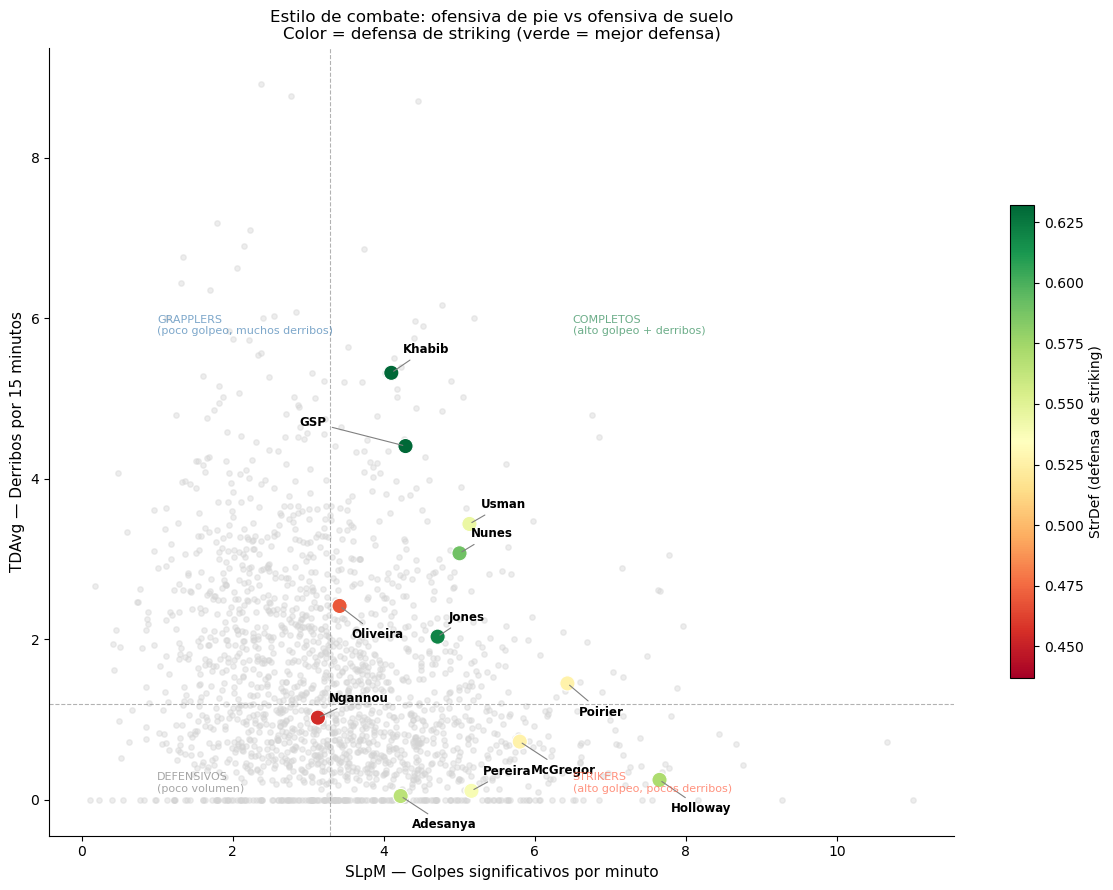

In [80]:
fig, ax = plt.subplots(figsize=(12,9))

# Todos los peleadores en color gris de fondo
ax.scatter(career['SLpM'], career['TDAvg'],
          c='lightgray', s=15, alpha=0.4, zorder=1)

#Destacar con color según StrDef (defensa de golpes)
dest_df = career[career['FIGHTER'].isin(destacados)].copy()
sc = ax.scatter(dest_df['SLpM'], dest_df['TDAvg'],
                c=dest_df['StrDef'], cmap='RdYlGn',
                s=120, zorder=3, edgecolors='white', linewidths=0.8,
                vmin=career['StrDef'].quantile(0.1),
                vmax=career['StrDef'].quantile(0.9))

#Anotaciones con desplazamiento para evitar que se solapen
offsets = {
    'Khabib':   ( 0.15,  0.25),
    'Adesanya': ( 0.15, -0.40),
    'Jones':    ( 0.15,  0.20),
    'McGregor': ( 0.15, -0.40),
    'Usman':    ( 0.15,  0.20),
    'GSP':      (-1.40,  0.25),
    'Holloway': ( 0.15, -0.40),
    'Oliveira': ( 0.15, -0.40),
    'Ngannou':  ( 0.15,  0.20),
    'Nunes':    ( 0.15,  0.20),
    'Poirier':  ( 0.15, -0.40),
    'Pereira':  ( 0.15,  0.20),
}

for _, row in dest_df.iterrows():
    alias = destacados[row['FIGHTER']]
    dx, dy = offsets.get(alias, (0.15, 0.20))
    ax.annotate(alias,
               xy=(row['SLpM'], row['TDAvg']),
               xytext=(row['SLpM'] + dx, row['TDAvg'] + dy),
               fontsize=8.5, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

#Lineas de mediana como referencia de cuadrantes
med_slpm  = career['SLpM'].median()
med_tdavg = career['TDAvg'].median()
ax.axvline(med_slpm,  color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(med_tdavg, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
 
# Etiquetas de cuadrantes
ax.text(1.0,  5.8, 'GRAPPLERS\n(poco golpeo, muchos derribos)',
        fontsize=8, color='steelblue', alpha=0.7)
ax.text(6.5,  5.8, 'COMPLETOS\n(alto golpeo + derribos)',
        fontsize=8, color='seagreen', alpha=0.7)
ax.text(1.0,  0.1, 'DEFENSIVOS\n(poco volumen)',
        fontsize=8, color='gray', alpha=0.7)
ax.text(6.5,  0.1, 'STRIKERS\n(alto golpeo, pocos derribos)',
        fontsize=8, color='tomato', alpha=0.7)

plt.colorbar(sc, ax=ax, label='StrDef (defensa de striking)', shrink=0.6)
ax.set_xlabel('SLpM — Golpes significativos por minuto', fontsize=11)
ax.set_ylabel('TDAvg — Derribos por 15 minutos', fontsize=11)
ax.set_title('Estilo de combate: ofensiva de pie vs ofensiva de suelo\nColor = defensa de striking (verde = mejor defensa)', fontsize=12)
ax.spines[['top','right']].set_visible(False)
 
plt.tight_layout()
#plt.savefig("plots/02_scatter_estilos.png", dpi=150, bbox_inches='tight')
#plt.close()
#print("\nPlot 2 guardado: plots/02_scatter_estilos.png")

**PLOT 3**

Gráfico de radar o spider chart. Para este gráfico usamos valores NORMALIZADOS (percentil del peleador respecto al resto), no los valores crudos porque la escala de SLpM y StrDef son muy diferentes.

Percentil rank: qué fracción del roster está por debajo de este peleador

R equivalente: ecdf(career$SLpM)(valor)

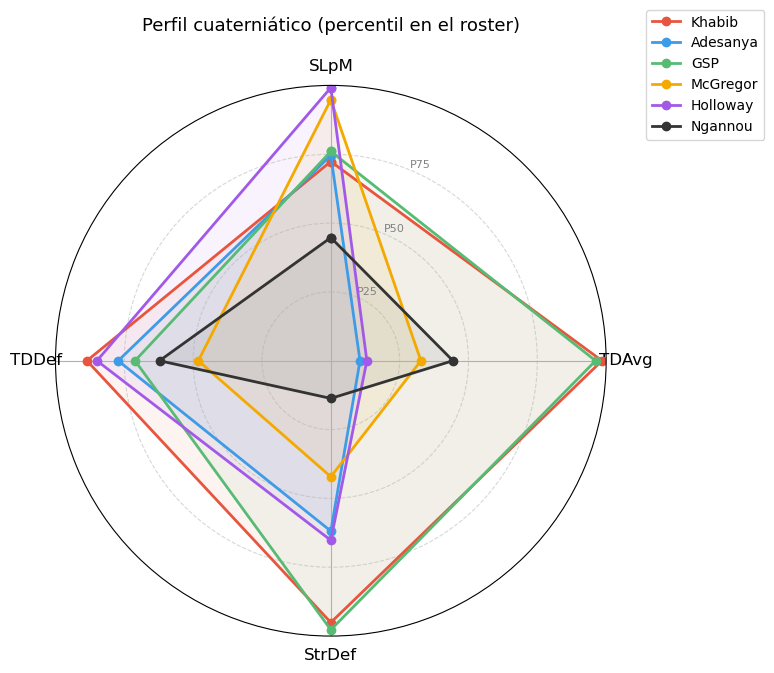

In [84]:
for m in metrics:
    career[f'{m}_pct'] = career[m].rank(pct=True)   # rank(pct=True) = percentile rank
 
radar_fighters = [
    'Khabib Nurmagomedov',
    'Israel Adesanya',
    'Georges St-Pierre',
    'Conor McGregor',
    'Max Holloway',
    'Francis Ngannou',
]
radar_labels = ['SLpM', 'TDAvg', 'StrDef', 'TDDef']
pct_cols     = [f'{m}_pct' for m in metrics]
 
N      = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # cerrar el polígono
 
colores_radar = ['#E8553E', '#3E9BE8', '#57BB73', '#F4A900', '#A259E8', '#333333']
 
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
 
for fighter, color in zip(radar_fighters, colores_radar):
    fila = career[career['FIGHTER'] == fighter]
    if fila.empty:
        continue
    vals = fila[pct_cols].values[0].tolist()
    vals += vals[:1]
    alias = destacados.get(fighter, fighter.split()[0])
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=alias)
    ax.fill(angles, vals, alpha=0.07, color=color)
 
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['P25', 'P50', 'P75'], fontsize=8, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
 
ax.set_title('Perfil cuaterniático (percentil en el roster)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)
 
plt.tight_layout()
#plt.savefig("plots/03_radar.png", dpi=150, bbox_inches='tight')
#plt.close()
#print("Plot 3 guardado: plots/03_radar.png")

**PLOT 4**

Top 10 por métrica.

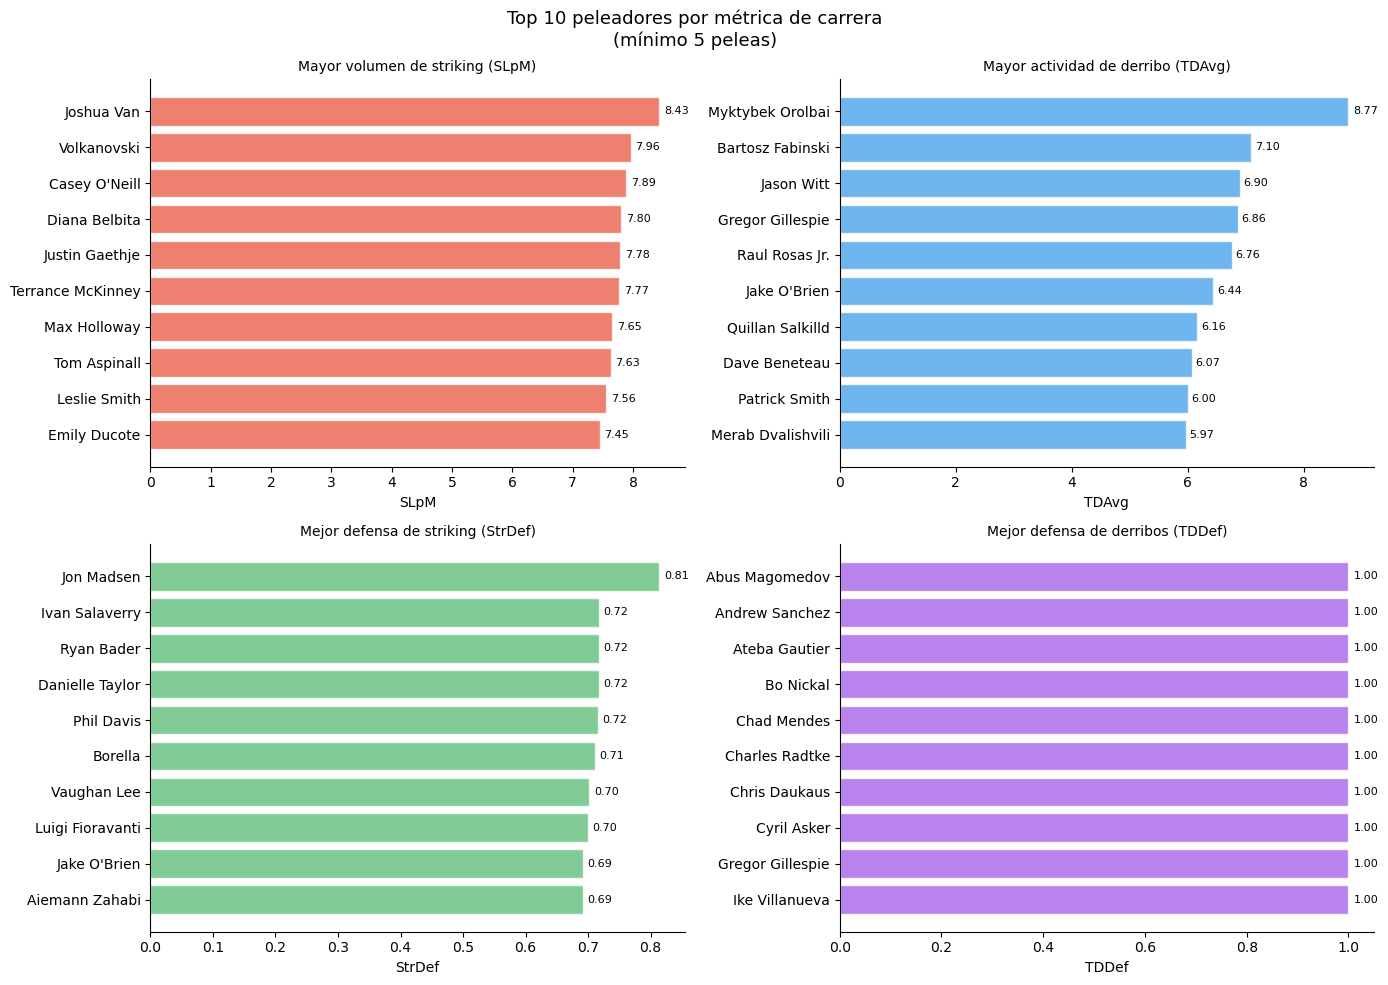

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Top 10 peleadores por métrica de carrera\n(mínimo 5 peleas)', fontsize=13)
 
career_5 = career[career['fights'] >= 5].copy()
 
titulos = {
    'SLpM':   'Mayor volumen de striking (SLpM)',
    'TDAvg':  'Mayor actividad de derribo (TDAvg)',
    'StrDef': 'Mejor defensa de striking (StrDef)',
    'TDDef':  'Mejor defensa de derribos (TDDef)',
}
 
for ax, metric, color in zip(axes.flat, metrics, colores):
    top = career_5.nlargest(10, metric)[['FIGHTER', metric]].iloc[::-1]
    # Abreviar nombres largos
    nombres = [n.split()[-1] if len(n) > 18 else n for n in top['FIGHTER']]
    bars = ax.barh(nombres, top[metric], color=color, alpha=0.75, edgecolor='white')
    for bar, val in zip(bars, top[metric]):
        ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)
    ax.set_title(titulos[metric], fontsize=10)
    ax.set_xlabel(metric)
    ax.spines[['top','right']].set_visible(False)
 
plt.tight_layout()
#plt.savefig("plots/04_top10.png", dpi=150, bbox_inches='tight')
#plt.close()
#print("Plot 4 guardado: plots/04_top10.png")

### Modelado 

Teóricamente habíamos concluído que los cuaterniones no iban a aportar una diferencia significativa de resultados en comparación con métodos tradicionales. Bueno, pasemos de la teoría a la práctica usando regresión logística.

.

.

Comparación: *features cuaterniónicas* vs *features tradicionales*

Pregunta: ¿El producto de Hamilton captura algo que una diferencia simple de stats no captura, a la hora de predecir quién gana una pelea?

Comparamos 3 representaciones:

A) Tradicional  (4 feat): diferencias de stats
$$ [Δf1 - Δf2] $$

B) Cuaterniático (4 feat): componentes de q1 × q2⁻¹

C) Concatenado  (8 feat): stats de ambos peleadores juntas

In [87]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [90]:
career_idx = career.set_index('FIGHTER') #índice para el lookup por nombre

**Verificación de los datos**

VERIFICAR: ¿primer peleador en BOUT = ganador?

ufcstats.com lista al ganador primero en cada pelea. Por si las dudas confirmamos con peleas cuyo resultado conocemos.

In [91]:
print("Verificación de convención BOUT (ganador primero)")

conocidas = [
    ('Khabib Nurmagomedov vs. Conor McGregor',   'Khabib gana sub. R4'),
    ('Israel Adesanya vs. Robert Whittaker',      'Adesanya gana KO R2'),
    ('Jon Jones vs. Thiago Santos',               'Jones gana dec. split'),
    ('Conor McGregor vs. Dustin Poirier',         'McGregor gana KO R1'),   # 2014
    ('Dustin Poirier vs. Conor McGregor',         'Poirier gana KO R2'),    # 2021
]

for bout, esperado in conocidas:
    row = results[results['BOUT'] == bout]
    if not row.empty:
        print(f"\n  Bout:     {bout}")
        print(f"  Esperado: {esperado}")
        print(f"  METHOD:   {row['METHOD'].values[0]}   R{row['ROUND'].values[0]}")

# Filtrar draws / no-contests / DQ (no son victorias limpias)
resultados_limpios = results[
    ~results['METHOD'].str.strip().str.contains(
        'Draw|No Contest|NC|DQ', case=False, na=False
    )
].drop_duplicates(subset=['BOUT'], keep='first').reset_index(drop=True)
 
print(f"\nTotal peleas limpias (sin draws/NC): {len(resultados_limpios):,}")

Verificación de convención BOUT (ganador primero)

  Bout:     Khabib Nurmagomedov vs. Conor McGregor
  Esperado: Khabib gana sub. R4
  METHOD:   Submission    R4

  Bout:     Israel Adesanya vs. Robert Whittaker
  Esperado: Adesanya gana KO R2
  METHOD:   Decision - Unanimous    R5

  Bout:     Jon Jones vs. Thiago Santos
  Esperado: Jones gana dec. split
  METHOD:   Decision - Split    R5

  Bout:     Dustin Poirier vs. Conor McGregor
  Esperado: Poirier gana KO R2
  METHOD:   TKO - Doctor's Stoppage    R1

Total peleas limpias (sin draws/NC): 8,544


Mmm, al parecer hay algunas inconsistencias en los rounds de victoria y el método de victoria. Arreglar eso en todo el dataset podría requerir hacer un esfuerzo considerable dado que tenemos una cantidad monstruosa de peleas registradas. Por el momento lo dejaremos así pero habrá que tenerlo en cuenta.

**CONSTRUIR LAS 3 MATRICES DE FEATURES**

Estrategia de pares simétricos: Por cada pelea generamos DOS ejemplos de entrenamiento.

Ejemplo 1 — "f1 gana":

$$features = stats(ganador) - stats(perdedor)       → y = 1$$

Ejemplo 2 — "f2 gana" (perspectiva invertida):

$$features = stats(perdedor) - stats(ganador)       → y = 0$$

Así las clases quedan perfectamente balanceadas (50/50) y el modelo aprende la dirección de la diferencia, no a quién se refieren las stats.

Para los features cuaterniónicos la lógica es la misma, pero en vez de restar usamos el cociente *q_ganador × q_perdedor⁻¹* (y su inverso).

In [93]:
X_trad   = []   # diferencias simples (4 feat)
X_quat   = []   # producto q1 × q2⁻¹  (4 feat)
X_concat = []   # concatenación directa (8 feat)
y        = []
omitidas = 0
 
for _, pelea in resultados_limpios.iterrows():
    bout = pelea['BOUT']
 
    # Parsear nombres
    sep    = ' vs. ' if ' vs. ' in bout else ' vs '
    partes = bout.split(sep)
    if len(partes) != 2:
        omitidas += 1
        continue
 
    f1_nombre = partes[0].strip()   # ganador (convención ufcstats)
    f2_nombre = partes[1].strip()   # perdedor

    # Verificar que tenemos stats de carrera para ambos
    if f1_nombre not in career_idx.index or f2_nombre not in career_idx.index:
        omitidas += 1
        continue
 
    f1 = career_idx.loc[f1_nombre, metrics].values.astype(float)
    f2 = career_idx.loc[f2_nombre, metrics].values.astype(float)
 
    # Feature A: diferencia simple
    diff = f1 - f2
 
    # Feature B: producto cuaterniático  q1 × q2⁻¹
    q1    = Quaternion(*f1)
    q2    = Quaternion(*f2)
    qr    = q1 * q2.inverse()  # ganador relativo al perdedor
    qr_i  = q2 * q1.inverse()  # perspectiva invertida
 
    # Ejemplo 1: ganador en posición f1 
    X_trad.append(diff)
    X_quat.append([qr.a, qr.b, qr.c, qr.d])
    X_concat.append(np.concatenate([f1, f2]))
    y.append(1)
 
    # Ejemplo 2: ganador en posición f2 (invertido)
    X_trad.append(-diff)
    X_quat.append([qr_i.a, qr_i.b, qr_i.c, qr_i.d])
    X_concat.append(np.concatenate([f2, f1]))
    y.append(0)


X_trad   = np.array(X_trad,   dtype=float)
X_quat   = np.array(X_quat,   dtype=float)
X_concat = np.array(X_concat, dtype=float)
y        = np.array(y)
 
print(f"\n{'=' * 60}")
print("- Datasets construidos -")
print(f"{'=' * 60}")
print(f"  Peleas usadas:    {len(y)//2:,}  (de {len(resultados_limpios):,})")
print(f"  Omitidas:         {omitidas:,}  (sin stats de carrera)")
print(f"  Ejemplos totales: {len(y):,}  ({y.sum():,} wins / {(y==0).sum():,} losses)")
print(f"  Balance de clases:{y.mean():.1%} positivos  ← debe ser 50%")


- Datasets construidos -
  Peleas usadas:    7,359  (de 8,544)
  Omitidas:         1,185  (sin stats de carrera)
  Ejemplos totales: 14,718  (7,359 wins / 7,359 losses)
  Balance de clases:50.0% positivos  ← debe ser 50%


**ENTRENAMIENTO Y EVALUACIÓN**

Usamos Pipeline(scaler + modelo) para evitar data leakage dentro del CV:

StandardScaler se ajusta SÓLO con los datos de entrenamiento de cada fold.

In [96]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
datasets = [
    ('Tradicional  (4 feat: Δstats)',     X_trad),
    ('Cuaterniático (4 feat: q1×q2⁻¹)', X_quat),
    ('Concatenado  (8 feat: raw stats)',  X_concat),
]
 
modelos = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=200, random_state=42)),
]
 
print(f"\n{'=' * 60}")
print("     Resultados  (accuracy, media ± std de 5 folds)")
print(f"{'=' * 60}")
print(f"  {'Features':<40} {'Logistic Reg':>15}  {'Random Forest':>15}")
print(f"  {'-'*40} {'-'*15}  {'-'*15}")

tabla = {}
for ds_nombre, X in datasets:
    fila = {}
    for m_nombre, modelo in modelos:
        pipe   = Pipeline([('sc', StandardScaler()), ('clf', modelo)])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
        fila[m_nombre] = scores
    tabla[ds_nombre] = fila
    lr = fila['Logistic Regression']
    rf = fila['Random Forest']
    print(f"  {ds_nombre:<40} {lr.mean():.3f} ± {lr.std():.3f}   {rf.mean():.3f} ± {rf.std():.3f}")
 
print(f"\n  {'Baseline (clase mayoritaria)':<40} {'0.500':>15}   {'0.500':>15}")


     Resultados  (accuracy, media ± std de 5 folds)
  Features                                    Logistic Reg    Random Forest
  ---------------------------------------- ---------------  ---------------
  Tradicional  (4 feat: Δstats)            0.553 ± 0.006   0.526 ± 0.008
  Cuaterniático (4 feat: q1×q2⁻¹)          0.530 ± 0.009   0.500 ± 0.007
  Concatenado  (8 feat: raw stats)         0.552 ± 0.007   0.566 ± 0.011

  Baseline (clase mayoritaria)                       0.500             0.500


**IMPORTANCIA DE FEATURES**

¿Cuál de las 4 métricas pesa más?

In [98]:
print("-- Importancia de features (Random Forest, 200 árboles) --")

for ds_nombre, X, feat_names in [
    ('Tradicional',   X_trad,   ['ΔSLpM', 'ΔTDAvg', 'ΔStrDef', 'ΔTDDef']),
    ('Cuaterniático', X_quat,   ['q(a) real', 'q(b) i', 'q(c) j', 'q(d) k']),
]:
    pipe_rf = Pipeline([
        ('sc',  StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ])
    pipe_rf.fit(X, y)
    imps = pipe_rf.named_steps['clf'].feature_importances_
 
    print(f"\n  {ds_nombre}:")
    for feat, imp in sorted(zip(feat_names, imps), key=lambda x: -x[1]):
        barra = '■' * int(imp * 80)
        print(f"    {feat:<12}  {imp:.3f}  {barra}")

-- Importancia de features (Random Forest, 200 árboles) --

  Tradicional:
    ΔStrDef       0.257  ■■■■■■■■■■■■■■■■■■■■
    ΔTDAvg        0.250  ■■■■■■■■■■■■■■■■■■■■
    ΔSLpM         0.247  ■■■■■■■■■■■■■■■■■■■
    ΔTDDef        0.245  ■■■■■■■■■■■■■■■■■■■

  Cuaterniático:
    q(a) real     0.254  ■■■■■■■■■■■■■■■■■■■■
    q(d) k        0.250  ■■■■■■■■■■■■■■■■■■■
    q(c) j        0.248  ■■■■■■■■■■■■■■■■■■■
    q(b) i        0.248  ■■■■■■■■■■■■■■■■■■■


**LECTURA DE RESULTADOS**

In [106]:
lr_trad = tabla['Tradicional  (4 feat: Δstats)']['Logistic Regression'].mean()
lr_quat = tabla['Cuaterniático (4 feat: q1×q2⁻¹)']['Logistic Regression'].mean()
rf_trad = tabla['Tradicional  (4 feat: Δstats)']['Random Forest'].mean()
rf_quat = tabla['Cuaterniático (4 feat: q1×q2⁻¹)']['Random Forest'].mean()
 
print(f"""
{'=' * 60}
                  Lectura de resultados
{'=' * 60}
 
  Diferencia LR  (trad - quat): {(lr_trad - lr_quat)*100:+.2f} pp
  Diferencia RF  (trad - quat): {(rf_trad - rf_quat)*100:+.2f} pp
 
  Ambos modelos superan el baseline (50%).
  La diferencia entre representaciones es {'pequeña (<2 pp)' if abs(lr_trad-lr_quat)<0.02 else 'notable (≥2 pp)'}.
""")


                  Lectura de resultados

  Diferencia LR  (trad - quat): +2.26 pp
  Diferencia RF  (trad - quat): +2.69 pp

  Ambos modelos superan el baseline (50%).
  La diferencia entre representaciones es notable (≥2 pp).



NOTA IMPORTANTE (Data Leakage):

Los career_stats de cada peleador se calcularon con TODAS sus peleas, incluidas las POSTERIORES al momento que predicemos.
 
Ejemplo: las stats de carrera de McGregor del año 2026 incluyen su derrota ante Poirier del 2021, que "no había ocurrido aún" en el momento de la pelea que estamos intentando predecir.
 
Esto infla la precisión de TODOS los modelos por igual, así que la comparación relativa entre ellos sigue siendo válida. Pero los números absolutos son más altos de lo que serían en producción.
 
Para un sistema real: habría que calcular las stats de carrera "como si fuera la fecha de la pelea" (solo peleas previas).